In [144]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [146]:
# Load the January and February 2020 event data
jan_df = pd.read_csv("2020-Jan.csv")
feb_df = pd.read_csv("2020-Feb.csv")

In [147]:
jan_df.shape

(4264752, 9)

In [150]:
feb_df.shape

(4156682, 9)

In [12]:
# Add a month column to identify the source month
jan_df["month"] = "January"
feb_df["month"] = "February"

In [13]:
# Combine January and February into one DataFrame
df = pd.concat([jan_df, feb_df], ignore_index=True)

In [15]:
df

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,month
0,2020-01-01 00:00:00 UTC,view,5809910,1602943681873052386,NaN,grattol,5.24,595414620,4adb70bb-edbd-4981-b60f-a05bfd32683a,January
1,2020-01-01 00:00:09 UTC,view,5812943,1487580012121948301,NaN,kinetics,3.97,595414640,c8c5205d-be43-4f1d-aa56-4828b8151c8a,January
2,2020-01-01 00:00:19 UTC,view,5798924,1783999068867920626,NaN,zinger,3.97,595412617,46a5010f-bd69-4fbe-a00d-bb17aa7b46f3,January
3,2020-01-01 00:00:24 UTC,view,5793052,1487580005754995573,NaN,NaN,4.92,420652863,546f6af3-a517-4752-a98b-80c4c5860711,January
4,2020-01-01 00:00:25 UTC,view,5899926,2115334439910245200,NaN,NaN,3.92,484071203,cff70ddf-529e-4b0c-a4fc-f43a749c0acb,January
...,...,...,...,...,...,...,...,...,...,...
8421429,2020-02-29 23:59:32 UTC,view,5885416,1487580005092295511,NaN,grattol,6.27,622082947,fb29909b-6ef5-4662-b4ee-288e73e5dc10,February
8421430,2020-02-29 23:59:39 UTC,cart,5550686,1487580008145748965,NaN,NaN,1.11,459705611,05d2add3-01f7-47ee-8364-27341673227f,February
8421431,2020-02-29 23:59:45 UTC,view,5850628,1602943681873052386,NaN,grattol,5.24,622090043,ab7d349f-db5d-4790-8ab1-31e5c894459d,February
8421432,2020-02-29 23:59:54 UTC,view,5716351,1487580010872045658,NaN,irisk,0.79,619841242,18af673b-7fb9-4202-a66d-5c855bc0fd2d,February


In [20]:
df.info() #display info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8421434 entries, 0 to 8421433
Data columns (total 10 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
 9   month          object 
dtypes: float64(1), int64(3), object(6)
memory usage: 642.5+ MB


In [22]:
# Check the number of missing values in each column
df.isnull().sum()

event_time             0
event_type             0
product_id             0
category_id            0
category_code    8269530
brand            3601538
price                  0
user_id                0
user_session        2369
month                  0
dtype: int64

In [24]:
# Display descriptive statistics for numerical columns
df.describe()

,product_id,category_id,price,user_id
count,8.421434e+06,8.421434e+06,8.421434e+06,8.421434e+06
mean,5.498318e+06,1.560378e+18,8.621121e+00,5.391882e+08
std,1.286741e+06,1.773420e+17,1.961062e+01,8.886411e+07
min,3.752000e+03,1.487580e+18,-7.937000e+01,4.654960e+05
25%,5.728072e+06,1.487580e+18,2.190000e+00,5.017526e+08
50%,5.813488e+06,1.487580e+18,4.110000e+00,5.720076e+08
75%,5.862067e+06,1.487580e+18,7.140000e+00,6.026324e+08
max,5.932595e+06,2.242903e+18,3.277800e+02,6.220902e+08


In [140]:
# Filter only purchase events
purchase_events = df[df["event_type"] == "purchase"].copy()
# Calculate the average price of purchased products
average_purchase_value = purchase_events["price"].mean()
# Calculate the maximum purchase price
max_purchase_value = purchase_events["price"].max()
print(f"Average purchase value: ${average_purchase_value:.2f}")
print(f"Maximum purchase value: ${max_purchase_value:.2f}")

Average purchase value: $5.00
Maximum purchase value: $327.78


In [142]:
# Count the number of purchases for each brand
brand_purchase_counts = (purchase_events["brand"].value_counts())
# Get the top 5 brands by purchase count
top_5_brands = brand_purchase_counts.head(5)
# Calculate the total number of purchases
total_purchases = brand_purchase_counts.sum()
# Calculate the percentage of total purchases generated by the top 5 brands
top_5_share = (top_5_brands.sum() / total_purchases) * 100
print("Top 5 brands:")
print(top_5_brands)
print(f"\nTop 5 brands account for {top_5_share:.2f}% of total purchases.")

Top 5 brands:
brand
runail      45274
irisk       31210
grattol     21320
masura      19929
ingarden    10276
Name: count, dtype: int64

Top 5 brands account for 44.69% of total purchases.


#### Inspect event type distribution

In [26]:
# Count the number of events for each event type
event_distribution = df["event_type"].value_counts()
event_distribution

event_type
view                3991194
cart                2297017
remove_from_cart    1627433
purchase             505790
Name: count, dtype: int64

#### Visualization

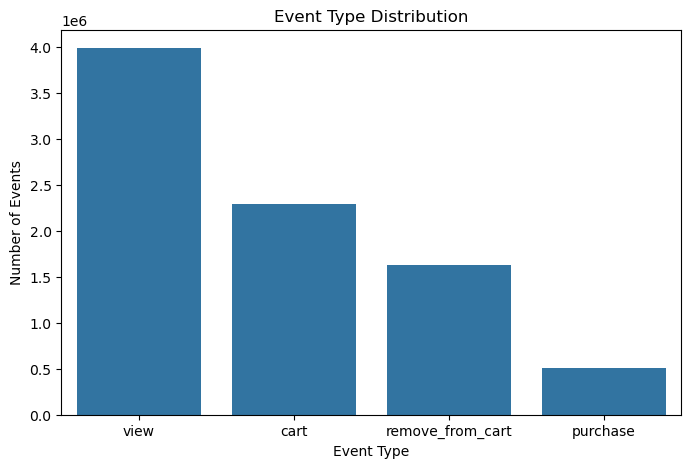

In [116]:
# Create a bar chart showing the number of events by event type
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x="event_type",
    order=df["event_type"].value_counts().index)
plt.title("Event Type Distribution")
plt.xlabel("Event Type")
plt.ylabel("Number of Events")
plt.show()

### Build the overall funnel

In [31]:
# Count unique users who viewed at least one product
view_users = df.loc[df["event_type"] == "view","user_id"].nunique()

# Count unique users who added at least one product to cart
cart_users = df.loc[df["event_type"] == "cart","user_id"].nunique()

# Count unique users who completed at least one purchase
purchase_users = df.loc[df["event_type"] == "purchase","user_id"].nunique()

# Store funnel results in a DataFrame
funnel = pd.DataFrame({"Stage": ["View", "Cart", "Purchase"],"Users": [view_users, cart_users, purchase_users]})

# Display the funnel table
funnel

,Stage,Users
0,View,716987
1,Cart,162035
2,Purchase,49473


### Calculate overall conversion rates

In [33]:
# Calculate conversion rate from view to cart
view_to_cart = (cart_users / view_users) * 100

# Calculate conversion rate from cart to purchase
cart_to_purchase = (purchase_users / cart_users) * 100

# Calculate conversion rate from view to purchase
view_to_purchase = (purchase_users / view_users) * 100

# Display the conversion rates
print(f"View ---> Cart Conversion: {view_to_cart:.2f}%")
print(f"Cart ---> Purchase Conversion: {cart_to_purchase:.2f}%")
print(f"View ---> Purchase Conversion: {view_to_purchase:.2f}%")

View ---> Cart Conversion: 22.60%
Cart ---> Purchase Conversion: 30.53%
View ---> Purchase Conversion: 6.90%


### Funnel bar chart

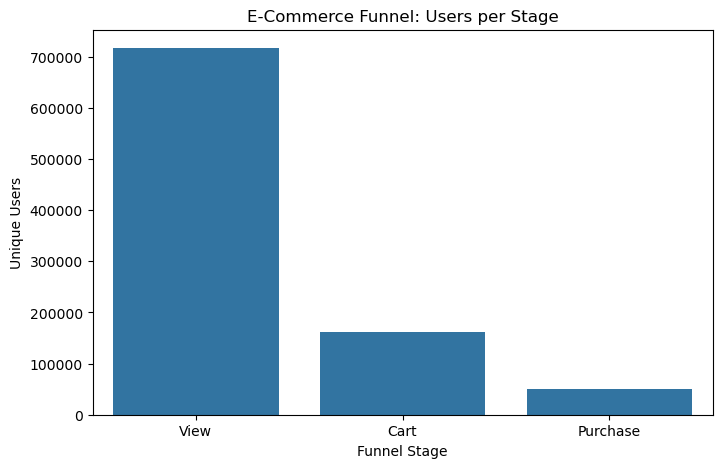

In [35]:
# Create a bar chart for the number of users at each funnel stage
plt.figure(figsize=(8, 5))
sns.barplot(data=funnel, x="Stage", y="Users")
plt.title("E-Commerce Funnel: Users per Stage")
plt.xlabel("Funnel Stage")
plt.ylabel("Unique Users")
plt.show()

### Funnel analysis by category

In [37]:
# Filter only view events
view_events = df[df["event_type"] == "view"]
category_view_counts = (view_events.groupby("category_code").size().sort_values(ascending=False))
top_8_categories = category_view_counts.head(8).index
print(top_8_categories)

Index(['appliances.environment.vacuum', 'furniture.living_room.cabinet',
       'apparel.glove', 'stationery.cartrige', 'accessories.bag',
       'furniture.bathroom.bath', 'appliances.personal.massager',
       'appliances.personal.hair_cutter'],
      dtype='object', name='category_code')


### Calculate funnel metrics for top 8 categories

In [39]:
# Create an empty list to store category-level funnel results
category_results = []
# Loop through each of the top 8 categories
for category in top_8_categories:
    
    # Select events belonging to the current category
    category_df = df[df["category_code"] == category]
    
    # Count unique users who viewed the category
    views = category_df.loc[category_df["event_type"] == "view","user_id"].nunique()
    
    # Count unique users who added the category to cart
    carts = category_df.loc[category_df["event_type"] == "cart", "user_id"].nunique()
    
    # Count unique users who purchased the category
    purchases = category_df.loc[category_df["event_type"] == "purchase","user_id"].nunique()
    
    # Calculate view-to-cart conversion
    view_cart_rate = (carts / views * 100) if views > 0 else 0
    
    # Calculate cart-to-purchase conversion
    cart_purchase_rate = (purchases / carts * 100) if carts > 0 else 0
    
    # Calculate view-to-purchase conversion
    view_purchase_rate = (purchases / views * 100) if views > 0 else 0
    
    # Store the results
    category_results.append({
        "category_code": category,
        "view_users": views,
        "cart_users": carts,
        "purchase_users": purchases,
        "view_to_cart_%": view_cart_rate,
        "cart_to_purchase_%": cart_purchase_rate,
        "view_to_purchase_%": view_purchase_rate})

# Convert the results into a DataFrame
category_funnel = pd.DataFrame(category_results)

# Sort categories by view-to-purchase conversion
category_funnel = category_funnel.sort_values("view_to_purchase_%", ascending=False)
category_funnel

,category_code,view_users,cart_users,purchase_users,view_to_cart_%,cart_to_purchase_%,view_to_purchase_%
2,apparel.glove,4965,4128,1932,83.141994,46.802326,38.912387
3,stationery.cartrige,4313,2265,1025,52.515650,45.253863,23.765361
5,furniture.bathroom.bath,3602,1164,384,32.315380,32.989691,10.660744
0,appliances.environment.vacuum,15431,3883,1366,25.163632,35.178985,8.852310
6,appliances.personal.massager,1335,151,35,11.310861,23.178808,2.621723
7,appliances.personal.hair_cutter,1141,113,28,9.903593,24.778761,2.453988
1,furniture.living_room.cabinet,5377,760,119,14.134276,15.657895,2.213130
4,accessories.bag,3147,146,45,4.639339,30.821918,1.429933


### Conversion rate by category visualization

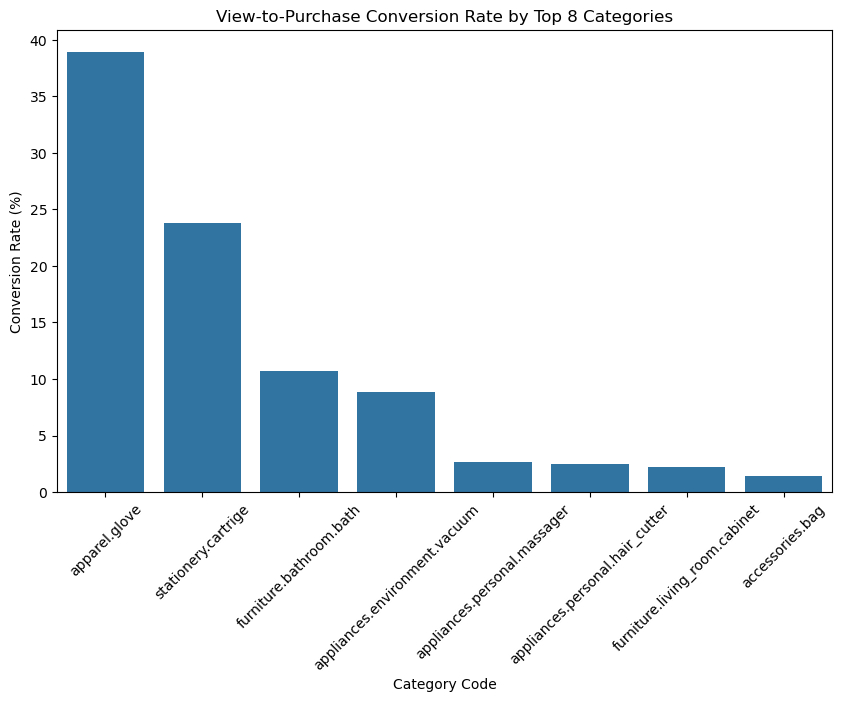

In [41]:
# Create a bar chart showing view-to-purchase conversion by category
plt.figure(figsize=(10, 6))
sns.barplot(data=category_funnel, x="category_code", y="view_to_purchase_%")
plt.title("View-to-Purchase Conversion Rate by Top 8 Categories")
plt.xlabel("Category Code")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45)
plt.show()

### January vs February comparison

In [43]:
# Create an empty list to store monthly funnel results
monthly_results = []
# Loop through January and February
for month in ["January", "February"]:
    
    # Filter data for the current month
    month_df = df[df["month"] == month]
    
    # Count unique users at each funnel stage
    views = month_df.loc[month_df["event_type"] == "view","user_id"].nunique()
    
    carts = month_df.loc[month_df["event_type"] == "cart","user_id"].nunique()
    
    purchases = month_df.loc[month_df["event_type"] == "purchase", "user_id"].nunique()
    
    # Calculate conversion rates
    view_cart = carts / views * 100 if views > 0 else 0
    cart_purchase = purchases / carts * 100 if carts > 0 else 0
    view_purchase = purchases / views * 100 if views > 0 else 0
    
    # Store monthly results
    monthly_results.append({
        "month": month,
        "view_users": views,
        "cart_users": carts,
        "purchase_users": purchases,
        "view_to_cart_%": view_cart,
        "cart_to_purchase_%": cart_purchase,
        "view_to_purchase_%": view_purchase})
monthly_funnel = pd.DataFrame(monthly_results)
monthly_funnel

,month,view_users,cart_users,purchase_users,view_to_cart_%,cart_to_purchase_%,view_to_purchase_%
0,January,397775,92653,28220,23.292816,30.457729,7.094463
1,February,379246,89269,25759,23.538548,28.855482,6.792161


### January vs February visualization

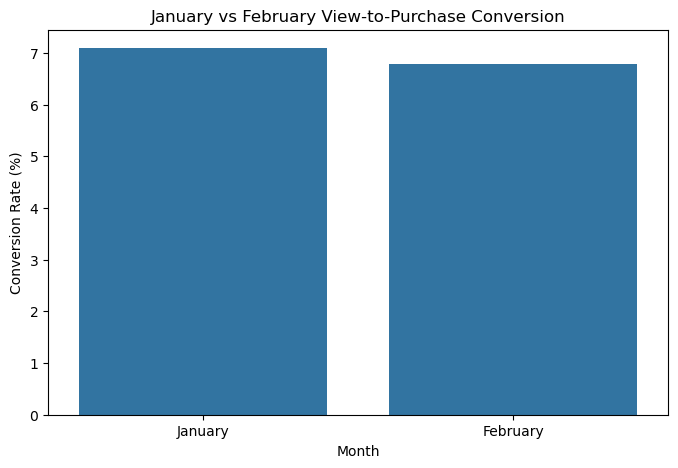

In [49]:
# Create a bar chart comparing view-to-purchase conversion
plt.figure(figsize=(8, 5))
sns.barplot(data=monthly_funnel, x="month", y="view_to_purchase_%")
plt.title("January vs February View-to-Purchase Conversion")
plt.xlabel("Month")
plt.ylabel("Conversion Rate (%)")
plt.show()

### Determine whether conversion improved

In [51]:
# Extract January and February conversion rates
jan_conversion = monthly_funnel.loc[monthly_funnel["month"] == "January", "view_to_purchase_%"].iloc[0]

feb_conversion = monthly_funnel.loc[monthly_funnel["month"] == "February","view_to_purchase_%"].iloc[0]

# Compare the conversion rates
if feb_conversion > jan_conversion:
    print(f"Overall conversion improved in February by "f"{feb_conversion - jan_conversion:.2f} percentage points.")
elif feb_conversion < jan_conversion:
    print(f"Overall conversion decreased in February by "f"{jan_conversion - feb_conversion:.2f} percentage points.")
else:
    print("Overall conversion remained unchanged.")

Overall conversion decreased in February by 0.30 percentage points.


### Top 10 brands by purchase count

In [53]:
#Filter only purchase events
purchase_events = df[df["event_type"] == "purchase"]
#Count purchases for each brand
top_brands = (purchase_events["brand"].value_counts().head(10))
top_brands

brand
runail       45274
irisk        31210
grattol      21320
masura       19929
ingarden     10276
estel         8616
bpw.style     8437
uno           6871
italwax       6740
kapous        6370
Name: count, dtype: int64

### Calculate view-to-purchase rate for top brands

In [55]:
# Create an empty list to store brand-level results
brand_results = []
# Loop through the top 10 brands
for brand in top_brands.index:
    
    # Filter events for the current brand
    brand_df = df[df["brand"] == brand]
    
    # Count unique users who viewed the brand
    views = brand_df.loc[brand_df["event_type"] == "view","user_id"].nunique()
    
    # Count unique users who purchased the brand
    purchases = brand_df.loc[brand_df["event_type"] == "purchase","user_id"].nunique()
    
    # Calculate view-to-purchase conversion
    conversion = purchases / views * 100 if views > 0 else 0
    
    # Store the results
    brand_results.append({"brand": brand, 
                          "purchase_count": len(brand_df[brand_df["event_type"] == "purchase"]),
                            "view_users": views,
                            "purchase_users": purchases,
                            "view_to_purchase_%": conversion})
# Convert results into a DataFrame
brand_funnel = pd.DataFrame(brand_results)
brand_funnel = brand_funnel.sort_values("purchase_count",ascending=False)
brand_funnel

,brand,purchase_count,view_users,purchase_users,view_to_purchase_%
0,runail,45274,86823,15562,17.923822
1,irisk,31210,70510,13332,18.907956
2,grattol,21320,48870,7905,16.175568
3,masura,19929,35640,5401,15.154321
4,ingarden,10276,23716,4972,20.964750
5,estel,8616,40234,3994,9.926927
6,bpw.style,8437,13376,3070,22.951555
7,uno,6871,22313,4128,18.500426
8,italwax,6740,19923,2927,14.691563
9,kapous,6370,42289,3018,7.136608


### Top 10 brands horizontal bar chart

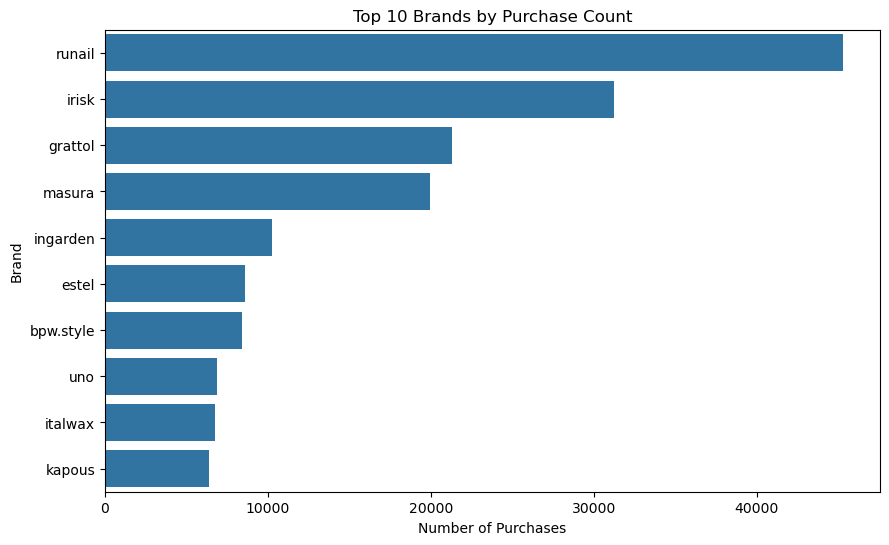

In [57]:
# Create a horizontal bar chart for the top 10 brands
plt.figure(figsize=(10, 6))
sns.barplot(data=brand_funnel,x="purchase_count",y="brand")
plt.title("Top 10 Brands by Purchase Count")
plt.xlabel("Number of Purchases")
plt.ylabel("Brand")
plt.show()

### Price outliers using IQR

In [59]:
# Select price values from purchase events
purchase_prices = purchase_events["price"].dropna()

# Calculate the first quartile
Q1 = purchase_prices.quantile(0.25)

# Calculate the third quartile
Q3 = purchase_prices.quantile(0.75)

# Calculate the Interquartile Range
IQR = Q3 - Q1

# Calculate the lower and upper outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify price outliers
price_outliers = purchase_events[(purchase_events["price"] < lower_bound) | (purchase_events["price"] > upper_bound)]

# Display IQR statistics
print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")

# Display the number of detected outliers
print(f"Number of price outliers: {len(price_outliers)}")

Q1: 1.59
Q3: 5.56
IQR: 3.97
Lower Bound: -4.37
Upper Bound: 11.52
Number of price outliers: 34947


### Outlier visualization

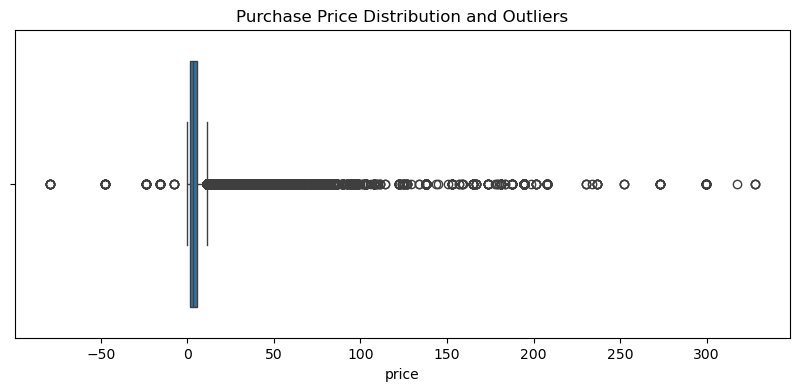

In [61]:
# Create a boxplot to visualize purchase price outliers
plt.figure(figsize=(10, 4))
sns.boxplot(x=purchase_prices)
plt.title("Purchase Price Distribution and Outliers")
plt.show()

### Average time between view and purchase

In [66]:
# Convert event_time to datetime format
df["event_time"] = pd.to_datetime(df["event_time"])

In [67]:
# Select only view and purchase events
view_purchase_events = df[df["event_type"].isin(["view", "purchase"])].copy()

# Sort events by user and event time
view_purchase_events = view_purchase_events.sort_values(["user_id", "event_time"])

In [68]:
# Find the first product view for each user
first_view = (
    view_purchase_events[view_purchase_events["event_type"] == "view"].groupby("user_id")["event_time"].min().rename("first_view_time"))
# Find the first purchase for each user
first_purchase = (view_purchase_events[view_purchase_events["event_type"] == "purchase"].groupby("user_id")["event_time"].min().rename("first_purchase_time"))

# Combine the first view and first purchase timestamps
conversion_time = pd.concat([first_view, first_purchase], axis=1).dropna()

In [70]:
# Keep only users whose purchase happened after their first view
conversion_time = conversion_time[conversion_time["first_purchase_time"] >= conversion_time["first_view_time"]].copy()

In [74]:
# Calculate the time between the first view and the first purchase
conversion_time["time_to_purchase_hours"] = (conversion_time["first_purchase_time"] - conversion_time["first_view_time"]).dt.total_seconds() / 3600
# Calculate the average conversion time
average_time_to_purchase = (conversion_time["time_to_purchase_hours"].mean())
print(f"Average time between view and purchase: "f"{average_time_to_purchase:.2f} hours")

Average time between view and purchase: 131.81 hours


### Frequently viewed but rarely purchased products

In [83]:
# Calculate the number of views for each product
product_views = (
    df[df["event_type"] == "view"].groupby("product_id").size().rename("view_count"))

# Calculate the number of purchases for each product
product_purchases = (df[df["event_type"] == "purchase"].groupby("product_id").size().rename("purchase_count"))

# Combine view and purchase counts
product_performance = pd.concat([product_views, product_purchases],axis=1).fillna(0)

# Calculate the view-to-purchase conversion rate
product_performance["view_to_purchase_%"] = (product_performance["purchase_count"] /product_performance["view_count"] * 100)

In [84]:
# Keep products with at least 100 views
# This removes products with very little traffic
high_view_products = product_performance[product_performance["view_count"] >= 100].copy()

In [93]:
# Sort products by view-to-purchase conversion rate
# Products with high views and low conversion will appear first
low_conversion_products = high_view_products.sort_values(["view_to_purchase_%", "view_count"], ascending=[True, False])
# Display the top 20 frequently viewed but rarely purchased products
low_conversion_products.head(20)

,view_count,purchase_count,view_to_purchase_%
product_id,,,
27759,1062.0,0.0,0.0
5678162,730.0,0.0,0.0
5893947,626.0,0.0,0.0
5906219,608.0,0.0,0.0
5894358,495.0,0.0,0.0
5706830,476.0,0.0,0.0
5770134,462.0,0.0,0.0
5703199,460.0,0.0,0.0
27845,453.0,0.0,0.0


In [95]:
# Calculate the 75th percentile of product views
high_view_threshold = product_performance["view_count"].quantile(0.75)

# Calculate the 25th percentile of conversion rate
low_conversion_threshold = product_performance[product_performance["view_count"] >= 100]["view_to_purchase_%"].quantile(0.25)

# Identify products with high traffic but low conversion
high_view_low_conversion = product_performance[(product_performance["view_count"] >= high_view_threshold) 
                            & (product_performance["view_to_purchase_%"] <= low_conversion_threshold)].sort_values("view_count",ascending=False)
high_view_low_conversion.head(20)

,view_count,purchase_count,view_to_purchase_%
product_id,,,
5808664,17194.0,23.0,0.133768
5917178,13930.0,344.0,2.469490
5790563,8081.0,418.0,5.172627
5924482,7842.0,214.0,2.728896
5877456,7800.0,21.0,0.269231
5856186,7761.0,79.0,1.017910
5769877,7608.0,66.0,0.867508
5850281,7482.0,80.0,1.069233
5877454,7230.0,82.0,1.134163


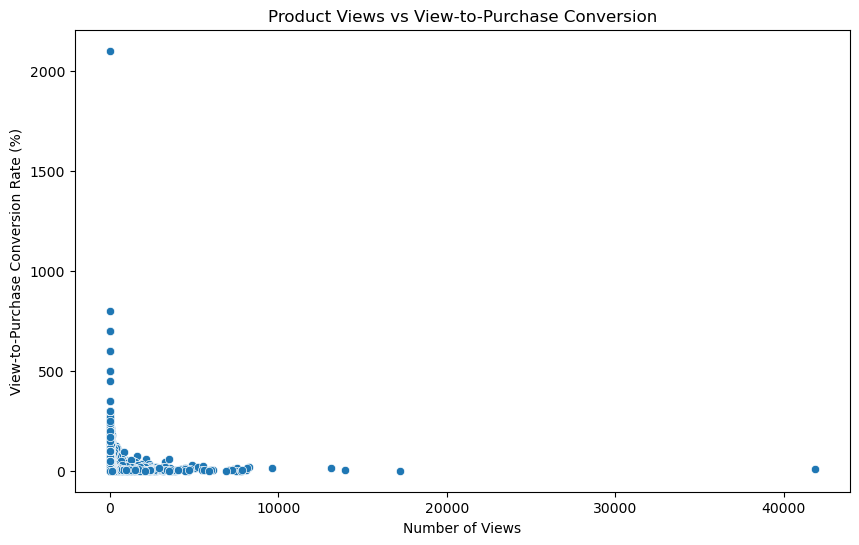

In [97]:
# Create a scatter plot of product views versus conversion rate
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=product_performance, x="view_count", y="view_to_purchase_%")
plt.title("Product Views vs View-to-Purchase Conversion")
plt.xlabel("Number of Views")
plt.ylabel("View-to-Purchase Conversion Rate (%)")
plt.show()

### Insights
1) The main drop-off occurs between views and cart additions

The View-to-Cart conversion rate is 22.60%, while the Cart-to-Purchase
conversion rate is higher at 30.53%. This indicates that a major
opportunity exists at the stage where users decide whether to add a
viewed product to their cart.
The product team should investigate product page experience, pricing,
product images, descriptions and the visibility of the "Add to Cart"
button to encourage more users to move from viewing products to adding
them to their cart. The overall View-to-Purchase conversion rate is
6.90%.

2) High-traffic products with critically low conversion rates

Certain individual products generate massive user traffic but fail to convert viewers into buyers. For instance, product 5808664 received the highest traffic with 17,194 views, yet achieved a view-to-purchase conversion rate of only 0.13% (23 purchases). Similarly, product 5915337 attracted 5,900 views but resulted in only 5 purchases (0.08% conversion rate).
These high-visibility items represent significant lost revenue potential. The product team should conduct a targeted audit of these specific product pages to address potential barriers, such as uncompetitive pricing, missing product specifications, poor image quality, or out-of-stock variations.

3) Overall conversion declined in February

The overall View-to-Purchase conversion rate decreased from 7.09% in
January to 6.79% in February. Interestingly, the View-to-Cart conversion
slightly improved from 23.29% to 23.54%, while the Cart-to-Purchase
conversion decreased from 30.46% to 28.86%.
This suggests that the main weakness in February occurred after users
added products to their carts. The product and growth teams should
investigate the checkout experience, delivery conditions, additional
costs and other possible barriers that may prevent users from completing
their purchases.

4) Brand Performance

Runail is the leading brand, with 45,274 purchases and 15,562 purchase users, significantly ahead of Irisk (31,210 purchases) and Grattol (21,320 purchases). However, InGarden has a higher view-to-purchase conversion rate (20.96%) than Runail (17.92%), indicating that Runail’s strong sales are mainly driven by high traffic, while InGarden appears more effective at converting viewers into buyers.

5) View → Purchase arasındakı orta müddətin 131.81 saat (~5.5 gün) olması müştərilərin alış qərarını gec verdiyini göstərir. Remarketing, reminder notification və fərdiləşdirilmiş təkliflər tətbiq etməklə bu müddəti azaltmaq və conversion-u artırmaq mümkündür.